# Week 5 - Day 2

Today was the second day of Week 5, and I continued learning about **Unsupervised Learning and Clustering**.

I focused on understanding different ways to group data and how to choose the right clustering method depending on the data. I learned about **DBSCAN** and **Hierarchical Clustering**, and I also compared them with **K-Means**.

During the practical part, I worked with different clustering examples, experimented with the main parameters, and visualized the results to better understand how each method works.

It was a useful day because I started to understand that choosing a machine learning algorithm depends on the data itself, not just on which algorithm is easier to use.


## 1. Why K-Means Is Not Always Enough

Today I learned that K-Means is useful for many clustering problems, but it does not work well for every type of dataset.

K-Means needs me to choose the number of clusters before training the model. It also works better when the clusters are relatively round and similar in size.

Another problem is that K-Means assigns every data point to a cluster, even if some points are clear outliers.

Because of this, I learned that I should choose another clustering method when the data has irregular shapes or many noise points.

### Example: Customer Locations

Imagine I have customer location data from a city. Some customers are grouped around a shopping mall, while others are grouped around a university. There are also a few customers who are far away from all the groups.

K-Means may not handle this situation well because it forces every point into a cluster and works better with round-shaped groups.

For this type of data, I would consider using DBSCAN because it can find irregularly shaped groups and identify points that do not belong to any cluster.

## 2. DBSCAN

I learned that DBSCAN is a density-based clustering algorithm.

Instead of asking me to choose the number of clusters, DBSCAN looks at how close the data points are to each other.

It can find clusters with irregular shapes, which makes it different from K-Means.

Another useful feature is that DBSCAN can identify points that do not belong to any cluster and mark them as noise.

This makes DBSCAN useful when my dataset contains outliers or clusters with non-round shapes.

## 3. DBSCAN Parameters

I learned that DBSCAN mainly depends on two important parameters: `eps` and `min_samples`.

The `eps` parameter controls how close two points need to be to be considered neighbors.

The `min_samples` parameter controls how many nearby points are needed to create a dense area.

Changing these values can change the clusters and the number of noise points, so I need to choose them carefully.

In [28]:
from sklearn.cluster import DBSCAN

model = DBSCAN(
    eps=0.5,
    min_samples=4
)

labels = model.fit_predict(X)


## 4. Hierarchical Clustering

I learned that hierarchical clustering builds a tree-like structure of clusters.

It starts by treating every data point as a separate cluster.

Then, it repeatedly merges the closest clusters until all points become part of one large cluster.

The result can be shown using a dendrogram.

One useful thing about this method is that I can look at the dendrogram and choose where to cut it depending on the number of clusters I want.

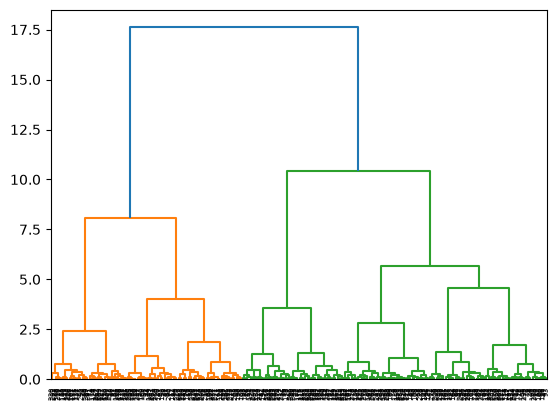

In [29]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(X, method="ward")

dendrogram(Z)

plt.show()

## 5. Comparing Clustering Methods

Today I also learned that there is no single clustering algorithm that is always the best.


# K-Means:

K-Means is a good choice when I already have an idea about the number of clusters and the clusters are relatively round and similar in size.

# DBSCAN:

DBSCAN is a better choice when my data contains noise or irregularly shaped clusters.

# Hierarchical Clustering:

Hierarchical clustering is useful when I want to understand the relationships between different groups and visualize the nested structure using a dendrogram.

The shape and characteristics of my data should guide my choice of clustering method.


# Hands-On: Comparing the Three Methods



For the practical part, I worked with the same dataset and applied three different clustering methods: K-Means, DBSCAN, and Hierarchical Clustering.

I compared the results instead of using only one algorithm.

I looked at the number of clusters, the noise points, and the shape of the groups produced by each method.

After comparing the results, I chose the method that fits the shape and characteristics of the dataset better and explained my choice.

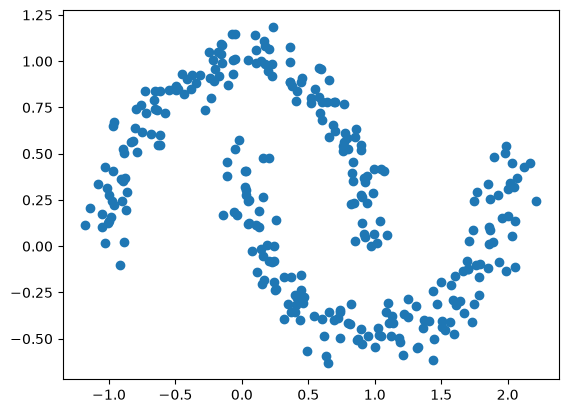

In [24]:
# use make_moons to generate a dataset

from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

X, y = make_moons(
    n_samples=300,
    noise=0.08,
    random_state=42
)

plt.scatter(X[:, 0], X[:, 1])
plt.show()

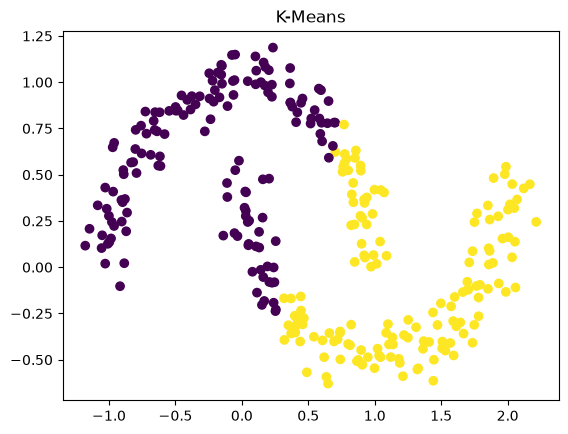

In [25]:
# K-Means clustering

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X)

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=kmeans_labels
)

plt.title("K-Means")
plt.show()

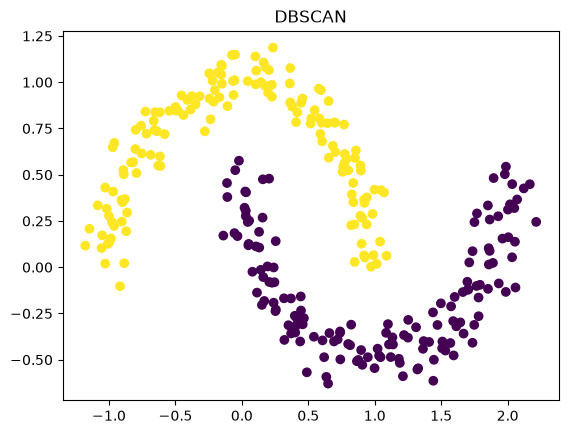

In [26]:
# DBSCAN clustering

from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.2,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X)

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=dbscan_labels
)

plt.title("DBSCAN")
plt.show()

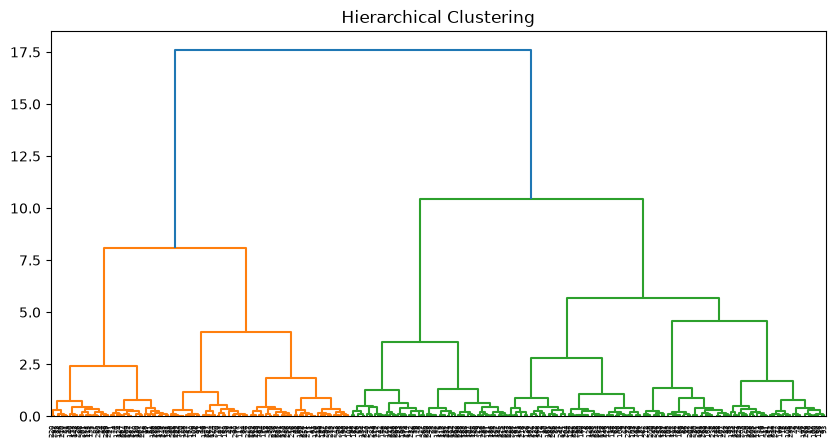

In [27]:
# Hierarchical clustering

from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(X, method="ward")

plt.figure(figsize=(10, 5))

dendrogram(Z)

plt.title("Hierarchical Clustering")
plt.show()

## Final Comparison

After comparing the three clustering methods, I noticed that each method behaves differently.

K-Means is simple and works well when the clusters have a suitable shape and I know the number of clusters.

DBSCAN is more suitable for this dataset because it can detect irregularly shaped clusters and does not require me to specify the number of clusters.

Hierarchical clustering gives me a different view of the data by showing how the points and clusters are connected through a dendrogram.

For this dataset, I would choose DBSCAN because its density-based approach fits the shape of the data better.

### Quick Summary

- **K-Means:** I need to choose `k`, and it works best with relatively round clusters.

- **DBSCAN:** I don't need to choose `k`. It works based on density and can detect noise.

- **Hierarchical Clustering:** It builds a tree of clusters and uses a dendrogram to show how they are connected.